In [1]:
!pip install pandas numpy matplotlib


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
calendar = pd.read_csv("../data/calendar.csv")
sales = pd.read_csv("../data/sales_train_validation.csv")
prices = pd.read_csv("../data/sell_prices.csv")

In [5]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [6]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [7]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [8]:
print("Calendar Shape:", calendar.shape)
print("Sales Shape:", sales.shape)
print("Prices Shape:", prices.shape)

Calendar Shape: (1969, 14)
Sales Shape: (30490, 1919)
Prices Shape: (6841121, 4)


In [9]:
calendar.columns

Index(['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI'],
      dtype='object')

In [10]:
sales.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4',
       ...
       'd_1904', 'd_1905', 'd_1906', 'd_1907', 'd_1908', 'd_1909', 'd_1910',
       'd_1911', 'd_1912', 'd_1913'],
      dtype='object', length=1919)

In [11]:
prices.columns

Index(['store_id', 'item_id', 'wm_yr_wk', 'sell_price'], dtype='object')

In [12]:
calendar.isnull().sum()

date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

In [13]:
sales.isnull().sum()

id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
           ..
d_1909      0
d_1910      0
d_1911      0
d_1912      0
d_1913      0
Length: 1919, dtype: int64

In [14]:
prices.isnull().sum()

store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

In [15]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB


In [16]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), object(6)
memory usage: 446.4+ MB


In [17]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    object 
 1   item_id     object 
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 208.8+ MB


In [18]:
calendar.describe(include="all")

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
count,1969,1969.000000,1969,1969.000000,1969.000000,1969.000000,1969,162,162,5,5,1969.000000,1969.000000,1969.000000
unique,1969,NaN,7,NaN,NaN,NaN,1969,30,4,4,2,NaN,NaN,NaN
top,2011-01-29,NaN,Saturday,NaN,NaN,NaN,d_1,SuperBowl,Religious,Father's day,Cultural,NaN,NaN,NaN
freq,1,NaN,282,NaN,NaN,NaN,1,6,55,2,4,NaN,NaN,NaN
mean,NaN,11347.086338,NaN,3.997461,6.325546,2013.288471,NaN,NaN,NaN,NaN,NaN,0.330117,0.330117,0.330117
std,NaN,155.277043,NaN,2.001141,3.416864,1.580198,NaN,NaN,NaN,NaN,NaN,0.470374,0.470374,0.470374
min,NaN,11101.000000,NaN,1.000000,1.000000,2011.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,11219.000000,NaN,2.000000,3.000000,2012.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
50%,NaN,11337.000000,NaN,4.000000,6.000000,2013.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
75%,NaN,11502.000000,NaN,6.000000,9.000000,2015.000000,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000


In [19]:
sales.describe()

,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
count,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,...,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000
mean,1.070220,1.041292,0.780026,0.833454,0.627944,0.958052,0.918662,1.244080,1.073663,0.838701,...,1.370581,1.586159,1.693670,1.248245,1.232207,1.159167,1.149000,1.328862,1.605838,1.633158
std,5.126689,5.365468,3.667454,4.415141,3.379344,4.785947,5.059495,6.617729,5.917204,4.206199,...,3.740017,4.097191,4.359809,3.276925,3.125471,2.876026,2.950364,3.358012,4.089422,3.812248
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000
max,360.000000,436.000000,207.000000,323.000000,296.000000,314.000000,316.000000,370.000000,385.000000,353.000000,...,129.000000,160.000000,204.000000,98.000000,100.000000,88.000000,77.000000,141.000000,171.000000,130.000000


In [20]:
prices.describe()

,wm_yr_wk,sell_price
count,6.841121e+06,6.841121e+06
mean,1.138294e+04,4.410952e+00
std,1.486100e+02,3.408814e+00
min,1.110100e+04,1.000000e-02
25%,1.124700e+04,2.180000e+00
50%,1.141100e+04,3.470000e+00
75%,1.151700e+04,5.840000e+00
max,1.162100e+04,1.073200e+02


In [3]:
import pandas as pd

calendar = pd.read_csv("../data/calendar.csv")
sales = pd.read_csv("../data/sales_train_validation.csv")
prices = pd.read_csv("../data/sell_prices.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [4]:
print("Calendar Dataset:", calendar.shape)
print("Sales Dataset:", sales.shape)
print("Prices Dataset:", prices.shape)

Calendar Dataset: (1969, 14)
Sales Dataset: (30490, 1919)
Prices Dataset: (6841121, 4)


In [3]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [4]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [5]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [6]:
print(calendar.isnull().sum())
print("-" * 50)
print(sales.isnull().sum())
print("-" * 50)
print(prices.isnull().sum())

date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64
--------------------------------------------------
id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
           ..
d_1909      0
d_1910      0
d_1911      0
d_1912      0
d_1913      0
Length: 1919, dtype: int64
--------------------------------------------------
store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64


In [ ]:
# Week 1 - Day 2

## Basic Data Exploration (EDA)

In [5]:
calendar.head()


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [6]:
sales.head() 

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [7]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [8]:
print("Calendar Shape:", calendar.shape)
print("Sales Shape:", sales.shape)
print("Prices Shape:", prices.shape)

Calendar Shape: (1969, 14)
Sales Shape: (30490, 1919)
Prices Shape: (6841121, 4)


In [9]:
print(calendar.columns)

print(sales.columns)

print(prices.columns)

Index(['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI'],
      dtype='object')
Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4',
       ...
       'd_1904', 'd_1905', 'd_1906', 'd_1907', 'd_1908', 'd_1909', 'd_1910',
       'd_1911', 'd_1912', 'd_1913'],
      dtype='object', length=1919)
Index(['store_id', 'item_id', 'wm_yr_wk', 'sell_price'], dtype='object')


In [10]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB


In [11]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), object(6)
memory usage: 446.4+ MB


In [12]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    object 
 1   item_id     object 
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 208.8+ MB


In [13]:
calendar.describe(include="all")

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
count,1969,1969.000000,1969,1969.000000,1969.000000,1969.000000,1969,162,162,5,5,1969.000000,1969.000000,1969.000000
unique,1969,NaN,7,NaN,NaN,NaN,1969,30,4,4,2,NaN,NaN,NaN
top,2011-01-29,NaN,Saturday,NaN,NaN,NaN,d_1,SuperBowl,Religious,Father's day,Cultural,NaN,NaN,NaN
freq,1,NaN,282,NaN,NaN,NaN,1,6,55,2,4,NaN,NaN,NaN
mean,NaN,11347.086338,NaN,3.997461,6.325546,2013.288471,NaN,NaN,NaN,NaN,NaN,0.330117,0.330117,0.330117
std,NaN,155.277043,NaN,2.001141,3.416864,1.580198,NaN,NaN,NaN,NaN,NaN,0.470374,0.470374,0.470374
min,NaN,11101.000000,NaN,1.000000,1.000000,2011.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,11219.000000,NaN,2.000000,3.000000,2012.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
50%,NaN,11337.000000,NaN,4.000000,6.000000,2013.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
75%,NaN,11502.000000,NaN,6.000000,9.000000,2015.000000,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000


In [14]:
sales.describe()

,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
count,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,...,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000
mean,1.070220,1.041292,0.780026,0.833454,0.627944,0.958052,0.918662,1.244080,1.073663,0.838701,...,1.370581,1.586159,1.693670,1.248245,1.232207,1.159167,1.149000,1.328862,1.605838,1.633158
std,5.126689,5.365468,3.667454,4.415141,3.379344,4.785947,5.059495,6.617729,5.917204,4.206199,...,3.740017,4.097191,4.359809,3.276925,3.125471,2.876026,2.950364,3.358012,4.089422,3.812248
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000
max,360.000000,436.000000,207.000000,323.000000,296.000000,314.000000,316.000000,370.000000,385.000000,353.000000,...,129.000000,160.000000,204.000000,98.000000,100.000000,88.000000,77.000000,141.000000,171.000000,130.000000


In [15]:
sales.describe()

,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
count,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,...,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000
mean,1.070220,1.041292,0.780026,0.833454,0.627944,0.958052,0.918662,1.244080,1.073663,0.838701,...,1.370581,1.586159,1.693670,1.248245,1.232207,1.159167,1.149000,1.328862,1.605838,1.633158
std,5.126689,5.365468,3.667454,4.415141,3.379344,4.785947,5.059495,6.617729,5.917204,4.206199,...,3.740017,4.097191,4.359809,3.276925,3.125471,2.876026,2.950364,3.358012,4.089422,3.812248
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000
max,360.000000,436.000000,207.000000,323.000000,296.000000,314.000000,316.000000,370.000000,385.000000,353.000000,...,129.000000,160.000000,204.000000,98.000000,100.000000,88.000000,77.000000,141.000000,171.000000,130.000000


In [2]:
# Week 1 - Day 4
## Duplicate Record Check

In [7]:
print("Sales duplicates:", sales.duplicated().sum())
print("Calendar duplicates:", calendar.duplicated().sum())
print("Prices duplicates:", prices.duplicated().sum())

Sales duplicates: 0
Calendar duplicates: 0
Prices duplicates: 0


In [8]:
## Data Type Verification

In [9]:
sales.dtypes

id          object
item_id     object
dept_id     object
cat_id      object
store_id    object
             ...  
d_1909       int64
d_1910       int64
d_1911       int64
d_1912       int64
d_1913       int64
Length: 1919, dtype: object

In [10]:
calendar.dtypes

date            object
wm_yr_wk         int64
weekday         object
wday             int64
month            int64
year             int64
d               object
event_name_1    object
event_type_1    object
event_name_2    object
event_type_2    object
snap_CA          int64
snap_TX          int64
snap_WI          int64
dtype: object

In [11]:
prices.dtypes

store_id       object
item_id        object
wm_yr_wk        int64
sell_price    float64
dtype: object

In [12]:
sales.memory_usage(deep=True)

Index          132
id         2370420
item_id    1882580
dept_id    1760620
cat_id     1699640
            ...   
d_1909      243920
d_1910      243920
d_1911      243920
d_1912      243920
d_1913      243920
Length: 1920, dtype: int64

In [13]:
calendar.memory_usage(deep=True)

Index              132
date            116171
wm_yr_wk         15752
weekday         110545
wday             15752
month            15752
year             15752
d               107188
event_name_1     67613
event_type_1     67113
event_name_2     63150
event_type_2     63134
snap_CA          15752
snap_TX          15752
snap_WI          15752
dtype: int64

In [14]:
prices.memory_usage(deep=True)

Index               132
store_id      362579413
item_id       422536778
wm_yr_wk       54728968
sell_price     54728968
dtype: int64

In [15]:
## Data Cleaning

In [4]:
calendar["date"] = pd.to_datetime(calendar["date"])

In [5]:
# Week 1 - Day 5
## Feature Engineering


In [6]:
# Ensure date column is datetime
calendar["date"] = pd.to_datetime(calendar["date"], errors="coerce")

# Create new date features
calendar["Year"] = calendar["date"].dt.year
calendar["Month"] = calendar["date"].dt.month
calendar["Day"] = calendar["date"].dt.day
calendar["Weekday"] = calendar["date"].dt.day_name()
calendar["Quarter"] = calendar["date"].dt.quarter

In [7]:
calendar[["date","Year","Month","Day","Weekday","Quarter"]].head(10)

,date,Year,Month,Day,Weekday,Quarter
0,2011-01-29,2011,1,29,Saturday,1
1,2011-01-30,2011,1,30,Sunday,1
2,2011-01-31,2011,1,31,Monday,1
3,2011-02-01,2011,2,1,Tuesday,1
4,2011-02-02,2011,2,2,Wednesday,1
5,2011-02-03,2011,2,3,Thursday,1
6,2011-02-04,2011,2,4,Friday,1
7,2011-02-05,2011,2,5,Saturday,1
8,2011-02-06,2011,2,6,Sunday,1
9,2011-02-07,2011,2,7,Monday,1


In [8]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1969 non-null   datetime64[ns]
 1   wm_yr_wk      1969 non-null   int64         
 2   weekday       1969 non-null   object        
 3   wday          1969 non-null   int64         
 4   month         1969 non-null   int64         
 5   year          1969 non-null   int64         
 6   d             1969 non-null   object        
 7   event_name_1  162 non-null    object        
 8   event_type_1  162 non-null    object        
 9   event_name_2  5 non-null      object        
 10  event_type_2  5 non-null      object        
 11  snap_CA       1969 non-null   int64         
 12  snap_TX       1969 non-null   int64         
 13  snap_WI       1969 non-null   int64         
 14  Year          1969 non-null   int32         
 15  Month         1969 non-null   int32   

In [9]:
## Feature Analysis

In [10]:
calendar["Weekday"].value_counts()

Weekday
Saturday     282
Sunday       282
Monday       281
Tuesday      281
Wednesday    281
Thursday     281
Friday       281
Name: count, dtype: int64

In [11]:
calendar["Weekday"].value_counts()

Weekday
Saturday     282
Sunday       282
Monday       281
Tuesday      281
Wednesday    281
Thursday     281
Friday       281
Name: count, dtype: int64

In [12]:
calendar["Quarter"].value_counts()

Quarter
2    535
1    514
3    460
4    460
Name: count, dtype: int64

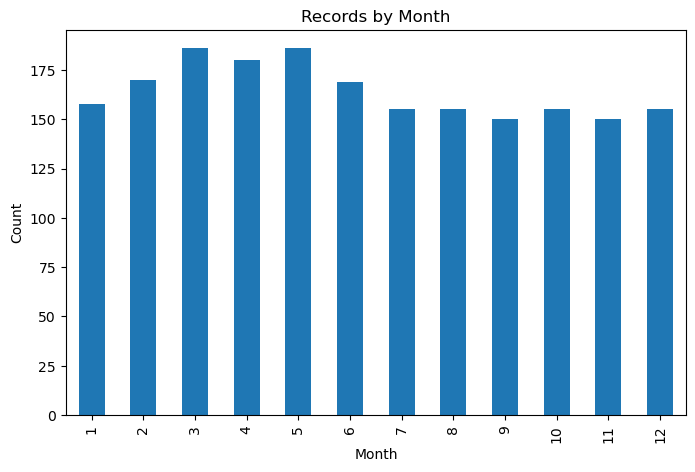

In [13]:
import matplotlib.pyplot as plt

calendar["Month"].value_counts().sort_index().plot(kind="bar", figsize=(8,5))

plt.title("Records by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

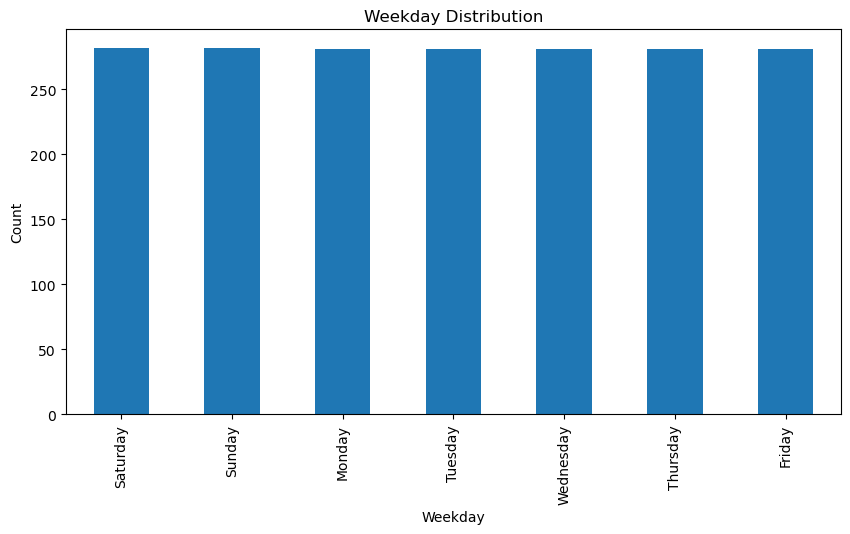

In [14]:
calendar["Weekday"].value_counts().plot(kind="bar", figsize=(10,5))

plt.title("Weekday Distribution")
plt.xlabel("Weekday")
plt.ylabel("Count")
plt.show()

In [15]:
print("Day 5 completed successfully!")

Day 5 completed successfully!


In [16]:
# Week 1 - Day 6
## Sales Trend Analysis

In [17]:
# Calculate total sales for each day
daily_sales = sales.iloc[:, 6:].sum()

daily_sales.head(10)

d_1     32631
d_2     31749
d_3     23783
d_4     25412
d_5     19146
d_6     29211
d_7     28010
d_8     37932
d_9     32736
d_10    25572
dtype: int64

In [18]:
print("Number of Days:", len(daily_sales))
print("Maximum Sales:", daily_sales.max())
print("Minimum Sales:", daily_sales.min())
print("Average Sales:", round(daily_sales.mean(), 2))

Number of Days: 1913
Maximum Sales: 57218
Minimum Sales: 11
Average Sales: 34341.56


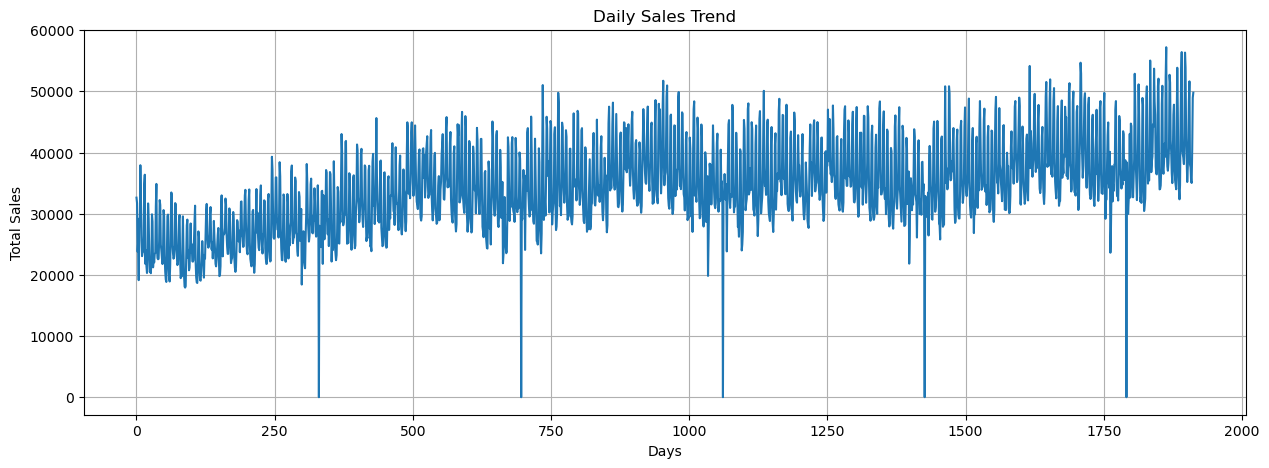

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(daily_sales.values)

plt.title("Daily Sales Trend")
plt.xlabel("Days")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

In [20]:
top_sales = daily_sales.sort_values(ascending=False).head(10)

top_sales

d_1864    57218
d_1892    56425
d_1898    56340
d_1835    55040
d_1709    54687
d_1617    54154
d_1884    53863
d_1899    53856
d_1842    53715
d_1710    52895
dtype: int64

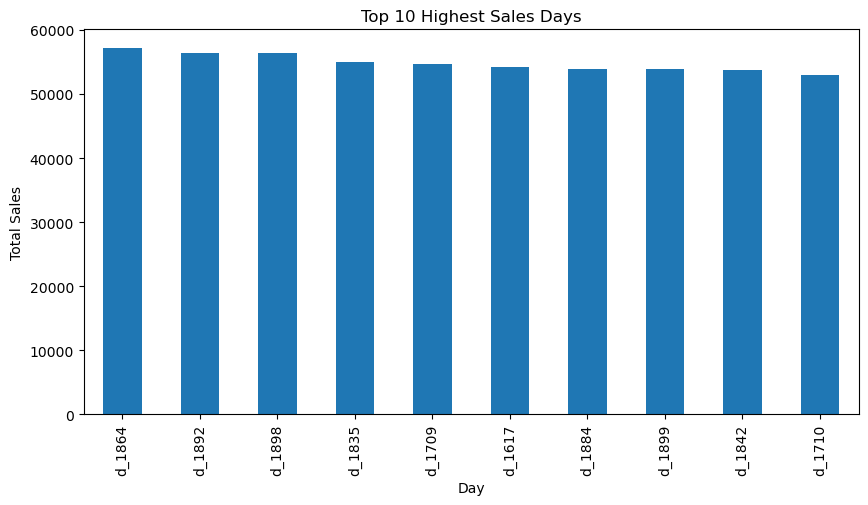

In [21]:
plt.figure(figsize=(10,5))

top_sales.plot(kind="bar")

plt.title("Top 10 Highest Sales Days")
plt.xlabel("Day")
plt.ylabel("Total Sales")

plt.show()

In [22]:
print("Highest Sales Day :", top_sales.index[0])
print("Highest Sales Value :", top_sales.iloc[0])

Highest Sales Day : d_1864
Highest Sales Value : 57218


In [24]:
print("Day 6 completed successfully!")

Day 6 completed successfully!


In [25]:
# Week 1 - Day 7
## Store-wise and Category-wise Sales Analysis

In [26]:
# Number of products in each store
store_sales = sales.groupby("store_id")["id"].count()

print(store_sales)

store_id
CA_1    3049
CA_2    3049
CA_3    3049
CA_4    3049
TX_1    3049
TX_2    3049
TX_3    3049
WI_1    3049
WI_2    3049
WI_3    3049
Name: id, dtype: int64


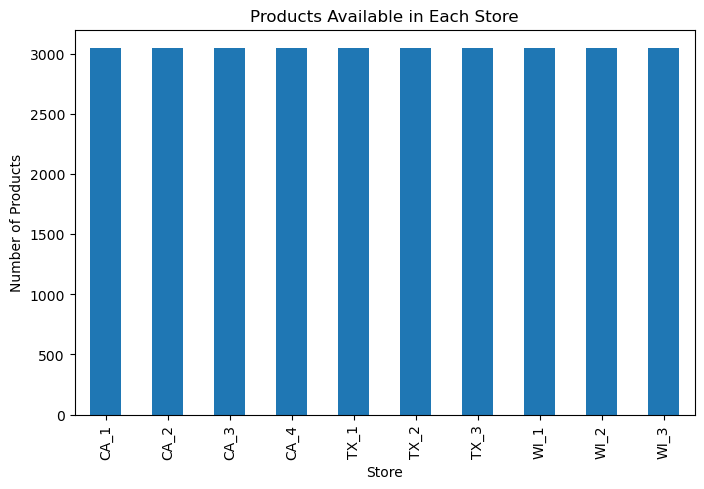

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
store_sales.plot(kind="bar")

plt.title("Products Available in Each Store")
plt.xlabel("Store")
plt.ylabel("Number of Products")

plt.show()

In [28]:
# Number of products in each category
category_sales = sales.groupby("cat_id")["id"].count()

print(category_sales)

cat_id
FOODS        14370
HOBBIES       5650
HOUSEHOLD    10470
Name: id, dtype: int64


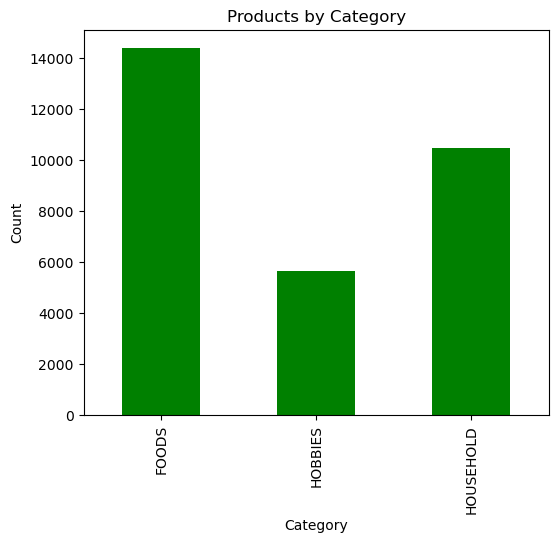

In [29]:
plt.figure(figsize=(6,5))
category_sales.plot(kind="bar", color="green")

plt.title("Products by Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

In [30]:
print("Day 7 completed successfully!")

Day 7 completed successfully!


In [31]:
# Week 2 - Day 8
## Department Analysis

In [32]:
department_sales = sales.groupby("dept_id")["id"].count()

department_sales

dept_id
FOODS_1        2160
FOODS_2        3980
FOODS_3        8230
HOBBIES_1      4160
HOBBIES_2      1490
HOUSEHOLD_1    5320
HOUSEHOLD_2    5150
Name: id, dtype: int64

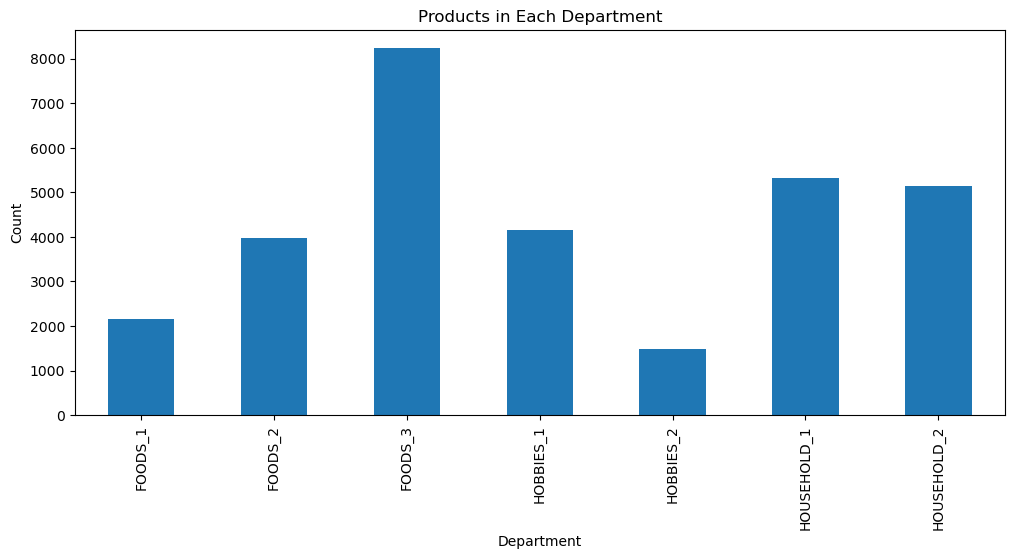

In [33]:
plt.figure(figsize=(12,5))
department_sales.plot(kind="bar")

plt.title("Products in Each Department")
plt.xlabel("Department")
plt.ylabel("Count")

plt.show()

In [34]:
print("Total Departments :", sales["dept_id"].nunique())
print("Total Categories :", sales["cat_id"].nunique())
print("Total Stores :", sales["store_id"].nunique())

Total Departments : 7
Total Categories : 3
Total Stores : 10


In [35]:
print("Day 8 completed successfully!")

Day 8 completed successfully!


In [36]:
# Week 2 - Day 9
## Dataset Summary and Forecast Preparation

In [37]:

print("Sales Dataset Shape :", sales.shape)
print("Calendar Dataset Shape :", calendar.shape)
print("Prices Dataset Shape :", prices.shape)

Sales Dataset Shape : (30490, 1919)
Calendar Dataset Shape : (1969, 19)
Prices Dataset Shape : (6841121, 4)


In [38]:
print("\nSales Columns:", len(sales.columns))
print("Calendar Columns:", len(calendar.columns))
print("Prices Columns:", len(prices.columns))


Sales Columns: 1919
Calendar Columns: 19
Prices Columns: 4


In [39]:
summary = {
    "Stores": sales["store_id"].nunique(),
    "Departments": sales["dept_id"].nunique(),
    "Categories": sales["cat_id"].nunique(),
    "Products": sales["item_id"].nunique()
}

summary

{'Stores': 10, 'Departments': 7, 'Categories': 3, 'Products': 3049}

In [40]:
summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])

summary_df

,Metric,Value
0,Stores,10
1,Departments,7
2,Categories,3
3,Products,3049


In [41]:

print("Dataset is now ready for forecasting and inventory optimisation.")

Dataset is now ready for forecasting and inventory optimisation.


In [42]:
# Week 2 - Day 10
## Dataset Integration for Forecasting

In [43]:
print("Sales Dataset:", sales.shape)
print("Calendar Dataset:", calendar.shape)
print("Prices Dataset:", prices.shape)

Sales Dataset: (30490, 1919)
Calendar Dataset: (1969, 19)
Prices Dataset: (6841121, 4)


In [44]:
print("Sales Columns:")
print(sales.columns[:10])

print("\nCalendar Columns:")
print(calendar.columns)

print("\nPrices Columns:")
print(prices.columns)

Sales Columns:
Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4'],
      dtype='object')

Calendar Columns:
Index(['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI', 'Year', 'Month', 'Day', 'Weekday',
       'Quarter'],
      dtype='object')

Prices Columns:
Index(['store_id', 'item_id', 'wm_yr_wk', 'sell_price'], dtype='object')


In [45]:
print("Sales Store IDs:", sales["store_id"].nunique())
print("Price Store IDs:", prices["store_id"].nunique())

print("Sales Item IDs:", sales["item_id"].nunique())
print("Price Item IDs:", prices["item_id"].nunique())

Sales Store IDs: 10
Price Store IDs: 10
Sales Item IDs: 3049
Price Item IDs: 3049


In [46]:
sales_price = pd.merge(
    sales[["item_id", "store_id"]],
    prices,
    on=["item_id", "store_id"],
    how="left"
)

sales_price.head()

,item_id,store_id,wm_yr_wk,sell_price
0,HOBBIES_1_001,CA_1,11325,9.58
1,HOBBIES_1_001,CA_1,11326,9.58
2,HOBBIES_1_001,CA_1,11327,8.26
3,HOBBIES_1_001,CA_1,11328,8.26
4,HOBBIES_1_001,CA_1,11329,8.26


In [47]:
print("Merged Dataset Shape:", sales_price.shape)

sales_price.info()

Merged Dataset Shape: (6841121, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   item_id     object 
 1   store_id    object 
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 208.8+ MB


In [48]:
sales_price.isnull().sum()

item_id       0
store_id      0
wm_yr_wk      0
sell_price    0
dtype: int64

In [49]:
print("Day 10 completed successfully!")
print("Sales and price datasets merged successfully.")

Day 10 completed successfully!
Sales and price datasets merged successfully.


In [3]:
# Week 2 - Day 11
## Exploratory Data Analysis

In [4]:
# Distribution of selling prices
prices["sell_price"].describe()

count    6.841121e+06
mean     4.410952e+00
std      3.408814e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.470000e+00
75%      5.840000e+00
max      1.073200e+02
Name: sell_price, dtype: float64

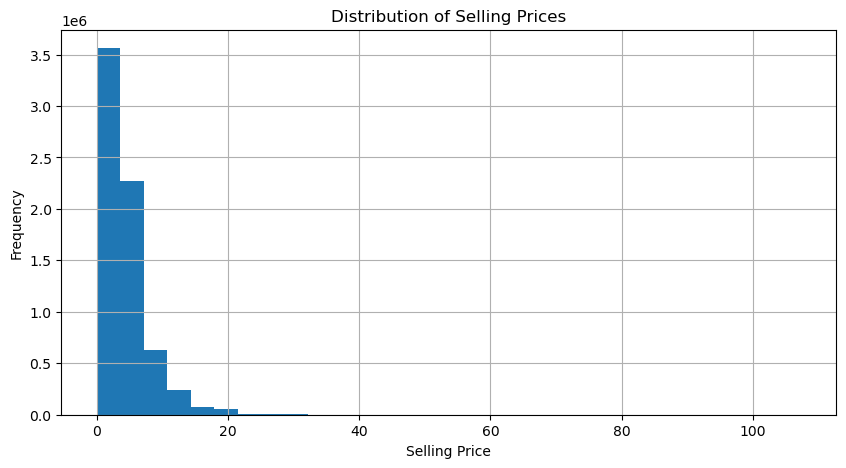

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
prices["sell_price"].hist(bins=30)

plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.show()

In [6]:
print("Minimum Price :", prices["sell_price"].min())
print("Maximum Price :", prices["sell_price"].max())
print("Average Price :", round(prices["sell_price"].mean(),2))

Minimum Price : 0.01
Maximum Price : 107.32
Average Price : 4.41


In [7]:
print("Day 11 completed successfully!")

Day 11 completed successfully!


In [8]:
# Week 2 - Day 12
## Category-wise Price Analysis

In [9]:
category_count = sales.groupby("cat_id")["item_id"].count()

category_count

cat_id
FOODS        14370
HOBBIES       5650
HOUSEHOLD    10470
Name: item_id, dtype: int64

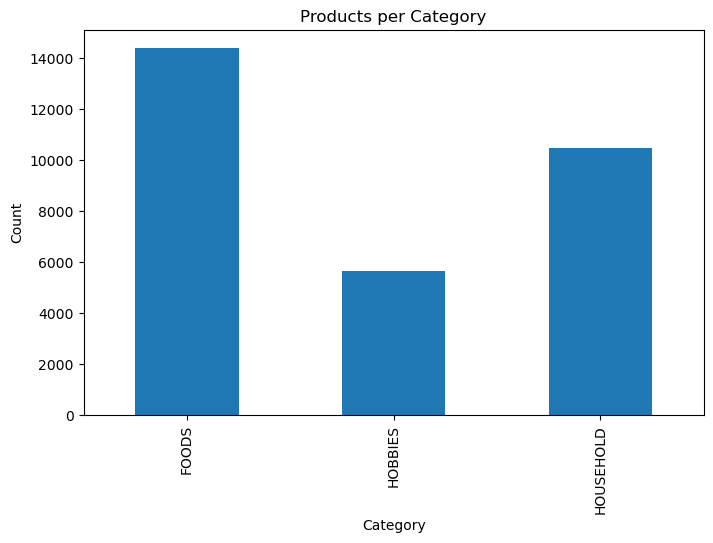

In [10]:
category_count.plot(kind="bar", figsize=(8,5))

plt.title("Products per Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

In [11]:
sales.groupby("store_id")["item_id"].count()

store_id
CA_1    3049
CA_2    3049
CA_3    3049
CA_4    3049
TX_1    3049
TX_2    3049
TX_3    3049
WI_1    3049
WI_2    3049
WI_3    3049
Name: item_id, dtype: int64

In [12]:
print("Day 12 completed successfully!")

Day 12 completed successfully!


In [13]:
# Week 2 - Day 13
## Sales Statistics

In [14]:
daily_sales = sales.iloc[:,6:].sum()

In [15]:
print("Mean Sales :", daily_sales.mean())
print("Median Sales :", daily_sales.median())
print("Maximum Sales :", daily_sales.max())
print("Minimum Sales :", daily_sales.min())

Mean Sales : 34341.562467328804
Median Sales : 33732.0
Maximum Sales : 57218
Minimum Sales : 11


In [16]:
daily_sales.describe()

count     1913.000000
mean     34341.562467
std       7345.905196
min         11.000000
25%      29654.000000
50%      33732.000000
75%      38689.000000
max      57218.000000
dtype: float64

In [17]:
print("Day 13 completed successfully!")

Day 13 completed successfully!


In [18]:
# Week 2 - Day 14
## Correlation Analysis and Project Summary

In [19]:
numeric_prices = prices.select_dtypes(include=["number"])

numeric_prices.corr()

,wm_yr_wk,sell_price
wm_yr_wk,1.000000,0.019475
sell_price,0.019475,1.000000


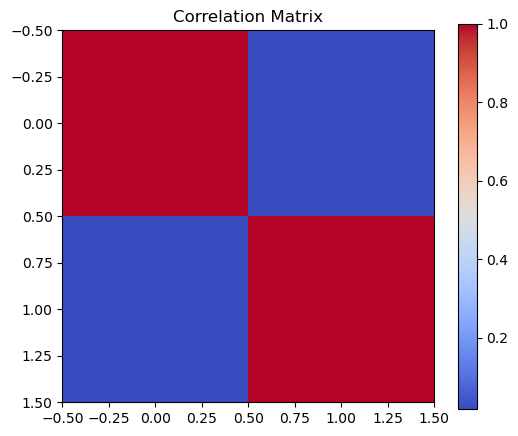

In [20]:
plt.figure(figsize=(6,5))

plt.imshow(numeric_prices.corr(), cmap="coolwarm")
plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

In [21]:
print("Sales Dataset :", sales.shape)
print("Calendar Dataset :", calendar.shape)
print("Prices Dataset :", prices.shape)

Sales Dataset : (30490, 1919)
Calendar Dataset : (1969, 14)
Prices Dataset : (6841121, 4)


In [22]:
print("Week 2 completed successfully!")
print("The project is now ready for demand forecasting model development.")

Week 2 completed successfully!
The project is now ready for demand forecasting model development.


In [23]:
# Week 3 - Day 15
## Daily Sales Aggregation

In [24]:
# Total daily sales
daily_sales = sales.iloc[:, 6:].sum()

daily_sales.head(10)

d_1     32631
d_2     31749
d_3     23783
d_4     25412
d_5     19146
d_6     29211
d_7     28010
d_8     37932
d_9     32736
d_10    25572
dtype: int64

In [25]:
print("Total Days:", len(daily_sales))
print("Average Daily Sales:", round(daily_sales.mean(), 2))

Total Days: 1913
Average Daily Sales: 34341.56


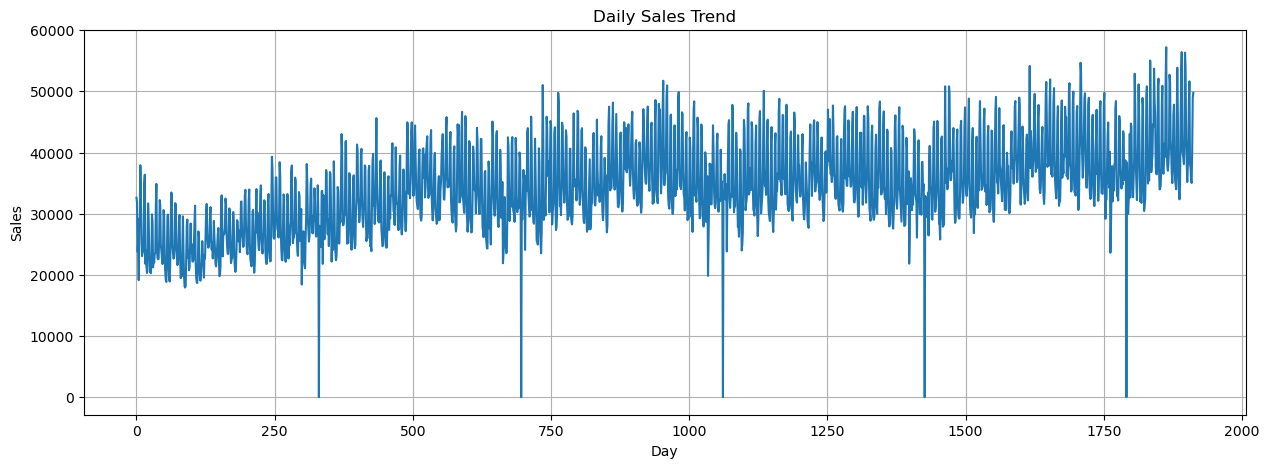

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(daily_sales.values)

plt.title("Daily Sales Trend")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

In [27]:
print("Highest Sales:", daily_sales.max())
print("Lowest Sales:", daily_sales.min())

Highest Sales: 57218
Lowest Sales: 11


In [28]:
# Week 3 - Day 16
## Selling Price Analysis

In [29]:
prices["sell_price"].describe()

count    6.841121e+06
mean     4.410952e+00
std      3.408814e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.470000e+00
75%      5.840000e+00
max      1.073200e+02
Name: sell_price, dtype: float64

In [30]:
print("Maximum Price:", prices["sell_price"].max())
print("Minimum Price:", prices["sell_price"].min())
print("Average Price:", round(prices["sell_price"].mean(),2))

Maximum Price: 107.32
Minimum Price: 0.01
Average Price: 4.41


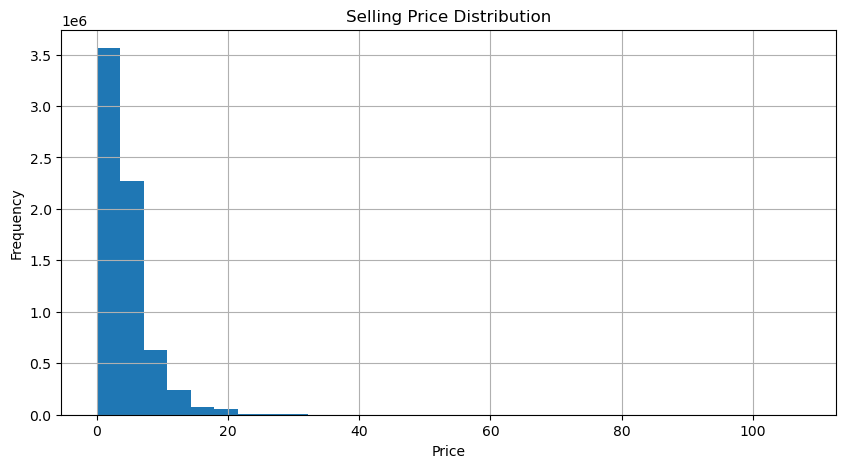

In [31]:
plt.figure(figsize=(10,5))

prices["sell_price"].hist(bins=30)

plt.title("Selling Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

In [32]:
# Week 3 - Day 17
## Store Analysis

In [33]:
store_count = sales["store_id"].value_counts()

store_count

store_id
CA_1    3049
CA_2    3049
CA_3    3049
CA_4    3049
TX_1    3049
TX_2    3049
TX_3    3049
WI_1    3049
WI_2    3049
WI_3    3049
Name: count, dtype: int64

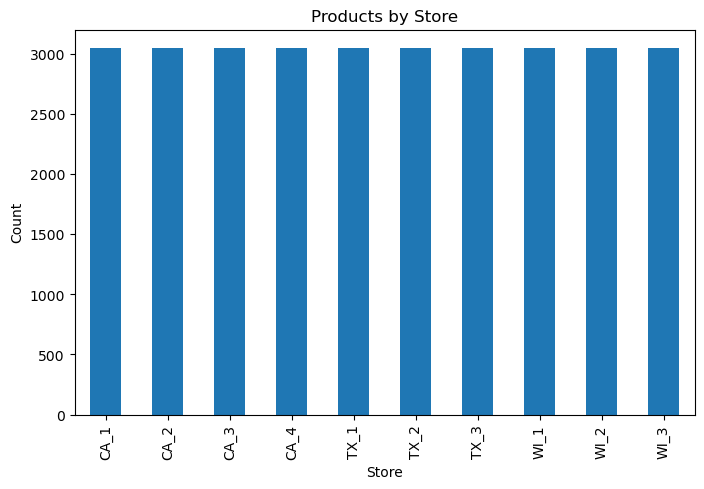

In [34]:
store_count.plot(kind="bar", figsize=(8,5))

plt.title("Products by Store")
plt.xlabel("Store")
plt.ylabel("Count")

plt.show()

In [35]:
category_count = sales["cat_id"].value_counts()

category_count

cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: int64

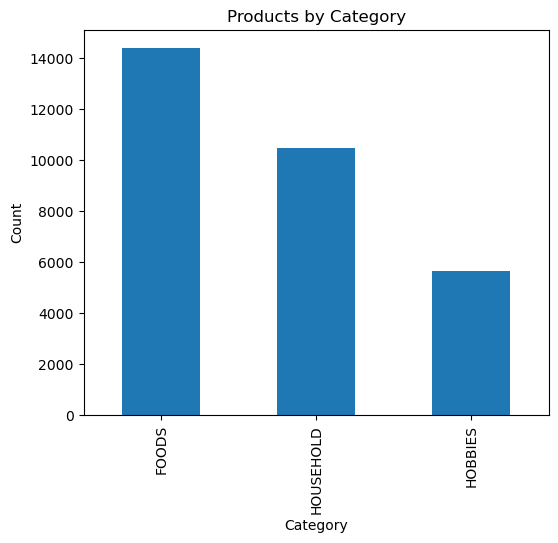

In [36]:
category_count.plot(kind="bar", figsize=(6,5))

plt.title("Products by Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

In [37]:
print("Day 17 completed successfully!")

Day 17 completed successfully!


In [4]:
# Week 3 - Day 18
## Preparing Dataset for Forecasting

In [5]:
# Select first 100 days for forecasting example
forecast_data = sales.iloc[:, 6:106]

forecast_data.head()

,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,...,d_91,d_92,d_93,d_94,d_95,d_96,d_97,d_98,d_99,d_100
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,1,1,1,2,0,0,1,0,1,3
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
print("Forecast Dataset Shape:", forecast_data.shape)

Forecast Dataset Shape: (30490, 100)


In [7]:
forecast_data.describe()


,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,...,d_91,d_92,d_93,d_94,d_95,d_96,d_97,d_98,d_99,d_100
count,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,...,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000
mean,1.070220,1.041292,0.780026,0.833454,0.627944,0.958052,0.918662,1.244080,1.073663,0.838701,...,0.745654,0.921646,0.952607,0.749000,0.789767,0.680912,0.694785,0.803083,0.931847,0.776910
std,5.126689,5.365468,3.667454,4.415141,3.379344,4.785947,5.059495,6.617729,5.917204,4.206199,...,2.893274,3.469550,3.810263,2.994469,3.117015,2.743477,2.823539,4.787469,3.864910,3.466385
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,360.000000,436.000000,207.000000,323.000000,296.000000,314.000000,316.000000,370.000000,385.000000,353.000000,...,93.000000,113.000000,131.000000,109.000000,101.000000,101.000000,89.000000,634.000000,152.000000,140.000000


In [8]:
print("Maximum Sales:", forecast_data.max().max())
print("Minimum Sales:", forecast_data.min().min())
print("Average Sales:", round(forecast_data.mean().mean(),2))

Maximum Sales: 634
Minimum Sales: 0
Average Sales: 0.82


In [9]:
print("Day 18 completed successfully!")

Day 18 completed successfully!


In [10]:
# Week 3 - Day 19
## Rolling Sales Analysis

In [11]:
daily_sales = sales.iloc[:,6:].sum()

rolling_mean = daily_sales.rolling(window=7).mean()

rolling_mean.head(15)

d_1              NaN
d_2              NaN
d_3              NaN
d_4              NaN
d_5              NaN
d_6              NaN
d_7     27134.571429
d_8     27891.857143
d_9     28032.857143
d_10    28288.428571
d_11    27954.000000
d_12    28598.571429
d_13    27819.285714
d_14    27595.714286
d_15    27153.000000
dtype: float64

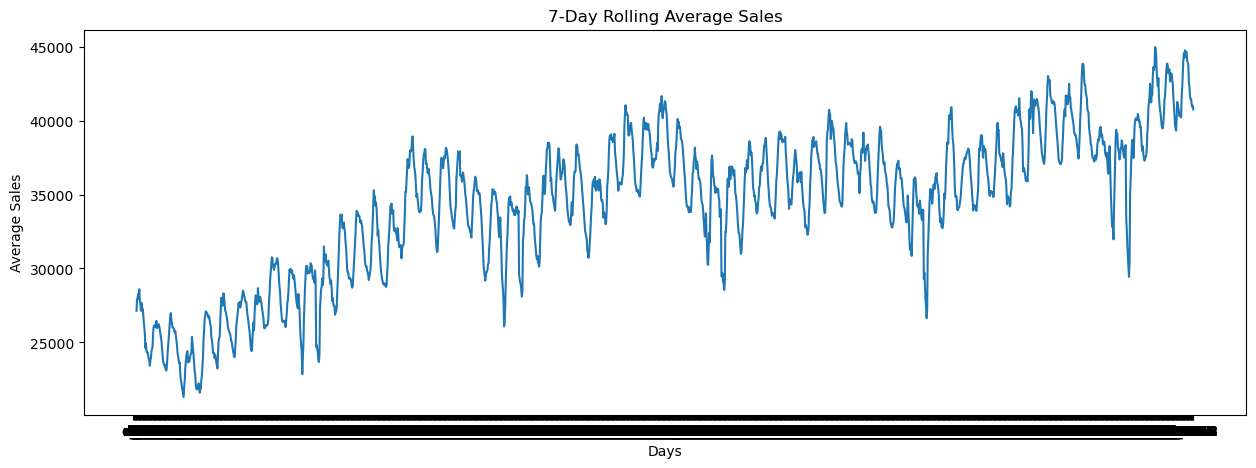

In [12]:
plt.figure(figsize=(15,5))
plt.plot(rolling_mean)

plt.title("7-Day Rolling Average Sales")
plt.xlabel("Days")
plt.ylabel("Average Sales")

plt.show()

In [13]:
rolling_std = daily_sales.rolling(window=7).std()

rolling_std.head()

d_1   NaN
d_2   NaN
d_3   NaN
d_4   NaN
d_5   NaN
dtype: float64

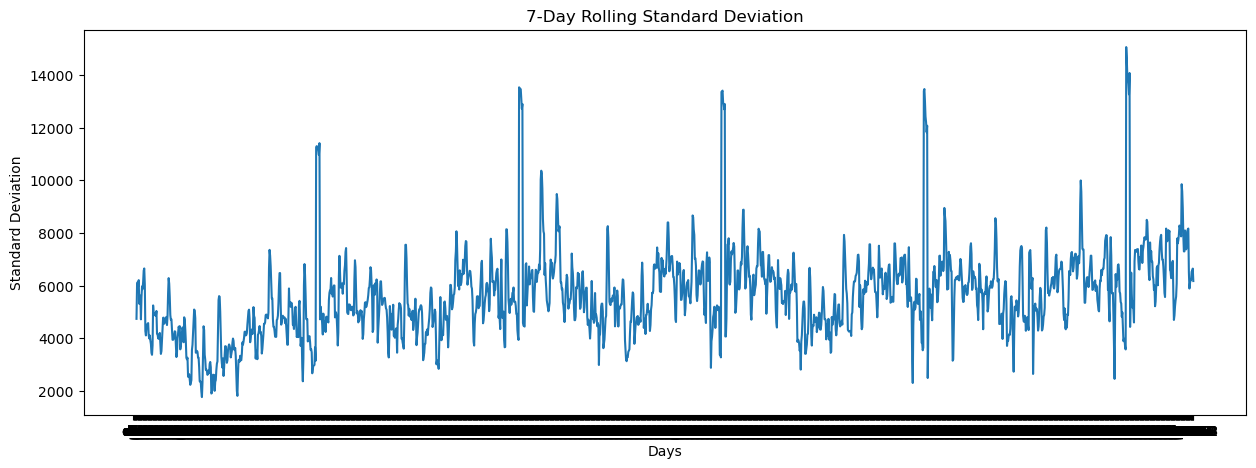

In [14]:
plt.figure(figsize=(15,5))
plt.plot(rolling_std)

plt.title("7-Day Rolling Standard Deviation")
plt.xlabel("Days")
plt.ylabel("Standard Deviation")

plt.show()

In [15]:
print("Day 19 completed successfully!")

Day 19 completed successfully!


In [16]:
# Week 3 - Day 20
## Time Series Preparation

In [17]:
time_series = pd.DataFrame({
    "Day": daily_sales.index,
    "Sales": daily_sales.values
})

time_series.head()

,Day,Sales
0,d_1,32631
1,d_2,31749
2,d_3,23783
3,d_4,25412
4,d_5,19146


In [18]:
print(time_series.shape)

(1913, 2)


In [23]:
time_series.to_csv("time_series_dataset.csv", index=False)

print("Dataset exported successfully!")

Dataset exported successfully!


In [24]:
time_series.tail()

,Day,Sales
1908,d_1909,35343
1909,d_1910,35033
1910,d_1911,40517
1911,d_1912,48962
1912,d_1913,49795


In [25]:
print("Day 20 completed successfully!")

Day 20 completed successfully!


In [6]:
# Create daily sales
daily_sales = sales.iloc[:, 6:].sum()

daily_sales.head()

d_1    32631
d_2    31749
d_3    23783
d_4    25412
d_5    19146
dtype: int64

In [7]:
# Create time series dataset
time_series = pd.DataFrame({
    "Day": daily_sales.index,
    "Sales": daily_sales.values
})

time_series.head()

,Day,Sales
0,d_1,32631
1,d_2,31749
2,d_3,23783
3,d_4,25412
4,d_5,19146


In [8]:
print(time_series.shape)

(1913, 2)


In [9]:
import os

os.makedirs("outputs", exist_ok=True)

In [10]:
time_series.to_csv("outputs/time_series_dataset.csv", index=False)

print("Dataset exported successfully!")

Dataset exported successfully!


In [11]:
time_series.tail()

,Day,Sales
1908,d_1909,35343
1909,d_1910,35033
1910,d_1911,40517
1911,d_1912,48962
1912,d_1913,49795


In [13]:
# Week 4 - Day 21
## Train-Test Split

In [14]:
# Split dataset into training and testing sets
train_data = time_series.iloc[:1700]
test_data = time_series.iloc[1700:]

print("Training Data Shape:", train_data.shape)
print("Testing Data Shape:", test_data.shape)

train_data.head()

Training Data Shape: (1700, 2)
Testing Data Shape: (213, 2)


,Day,Sales
0,d_1,32631
1,d_2,31749
2,d_3,23783
3,d_4,25412
4,d_5,19146


In [15]:
import os

os.makedirs("outputs", exist_ok=True)

train_data.to_csv("outputs/train_data.csv", index=False)
test_data.to_csv("outputs/test_data.csv", index=False)

print("Train and Test datasets exported successfully!")

Train and Test datasets exported successfully!


In [16]:
train_data.tail()

,Day,Sales
1695,d_1696,49979
1696,d_1697,36145
1697,d_1698,33518
1698,d_1699,33497
1699,d_1700,32967


In [17]:
# Week 4 - Day 22
## Moving Average Forecast

In [18]:
forecast = train_data["Sales"].rolling(window=7).mean()

forecast.head(15)

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
5              NaN
6     27134.571429
7     27891.857143
8     28032.857143
9     28288.428571
10    27954.000000
11    28598.571429
12    27819.285714
13    27595.714286
14    27153.000000
Name: Sales, dtype: float64

In [19]:
print("Forecast Length:", len(forecast))

Forecast Length: 1700
